# Apply — EDA on the anime dataset

Exploration that grounds the **triples** stage: what the raw fields actually look like,
how clean they are, and what the rating graph's shape implies for subsampling.

Sources (see `data/readme.md`): `anime.csv` (content) + `rating.csv` (edges),
both keyed on the MyAnimeList id. Both live in `Apply/data/` (gitignored).

In [2]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA = Path("data")

# Only the columns the ontology touches (+ a better year source than `year`).
ACOLS = ["mal_id","title","type","source","episodes","status","score","members","year",
         "aired_prop_from_year","producers","licensors","studios","genres","themes","demographics"]
anime = pd.read_csv(DATA / "anime.csv", usecols=ACOLS)
rating = pd.read_csv(DATA / "rating.csv")
print("anime rows:", len(anime), "| rating rows:", len(rating))

Matplotlib is building the font cache; this may take a moment.


anime rows: 28858 | rating rows: 7813737


## 1. anime.csv — shape, duplicates, missing

`wc -l` over-counts (embedded newlines in synopsis). The real question is distinct `mal_id`.

In [3]:
dupes = len(anime) - anime.mal_id.nunique()
print(f"rows={len(anime)}  unique mal_id={anime.mal_id.nunique()}  duplicate rows={dupes}")

# Dedup: keep first occurrence per mal_id (the id is our entity key).
anime = anime.drop_duplicates(subset="mal_id", keep="first").reset_index(drop=True)
print("after dedup:", len(anime))

miss = anime.isna().sum().sort_values(ascending=False)
miss_pct = (miss/len(anime)*100).round(1)
pd.DataFrame({"n_missing": miss, "pct": miss_pct})

rows=28858  unique mal_id=28627  duplicate rows=231
after dedup: 28627


,n_missing,pct
licensors,23491,82.1
year,22447,78.4
demographics,17921,62.6
producers,15122,52.8
themes,11767,41.1
studios,11592,40.5
score,9965,34.8
genres,5925,20.7
aired_prop_from_year,871,3.0
episodes,650,2.3


## 2. Single-valued categoricals → vocab hub nodes (`:AnimeType`, `:Source`)

These become `:animeType`/`:hasSource` edges to controlled-vocab individuals (decision D2).

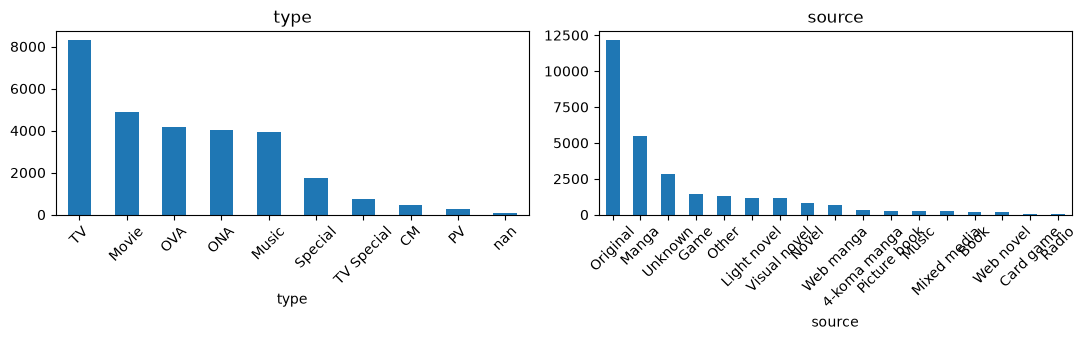

type vocab size: 9 | source vocab size: 17


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
anime.type.value_counts(dropna=False).plot.bar(ax=ax[0], title="type"); ax[0].tick_params(axis='x', rotation=45)
anime.source.value_counts(dropna=False).plot.bar(ax=ax[1], title="source"); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print("type vocab size:", anime.type.nunique(), "| source vocab size:", anime.source.nunique())

## 3. Multi-valued fields → object-property edges

`genres, themes, demographics, studios, producers, licensors` are comma-separated
(`", "`) strings. Each value becomes one node reused across anime — the shared nodes
that give the graph connectivity for embeddings/GNN. Measure fill-rate and vocab size.

In [5]:
MULTI = ["genres","themes","demographics","studios","producers","licensors"]

def split_multi(s):
    if pd.isna(s): return []
    return [t.strip() for t in str(s).split(",") if t.strip()]

rows = []
for col in MULTI:
    exploded = anime[col].map(split_multi)
    fill = (exploded.map(len) > 0).mean()*100
    vocab = set().union(*exploded) if len(exploded) else set()
    total_edges = exploded.map(len).sum()
    rows.append({"field": col, "fill_%": round(fill,1),
                 "vocab_size": len(vocab), "total_edges": int(total_edges),
                 "avg_per_anime": round(total_edges/len(anime),2)})
pd.DataFrame(rows).set_index("field")

,fill_%,vocab_size,total_edges,avg_per_anime
field,,,,
genres,79.3,21,42588,1.49
themes,58.9,52,24000,0.84
demographics,37.4,5,10763,0.38
studios,59.5,1270,18519,0.65
producers,47.2,1725,30680,1.07
licensors,17.9,91,6164,0.22


In [6]:
# Top values per field (what the hub nodes actually are).
for col in ["genres","themes","studios"]:
    vc = anime[col].map(split_multi).explode().value_counts().head(10)
    display(f"\n--- top {col} ---"); print(vc.to_string())

'\n--- top genres ---'

genres
Comedy           7724
Fantasy          5963
Action           5575
Adventure        4386
Sci-Fi           3438
Drama            3070
Romance          2178
Hentai           1583
Slice of Life    1559
Supernatural     1543


'\n--- top themes ---'

themes
Music              5026
School             2217
Historical         1706
Mecha              1312
Anthropomorphic    1203
Parody              800
Military            737
Super Power         717
Adult Cast          703
Martial Arts        703


'\n--- top studios ---'

studios
Toei Animation                    915
Sunrise                           580
J.C.Staff                         440
TMS Entertainment                 396
Madhouse                          380
Production I.G                    360
Shanghai Animation Film Studio    342
Studio Deen                       322
OLM                               303
Pierrot                           288


## 4. Temporal — `year` is unusable, `aired_prop_from_year` is not

`year` is ~78% NaN. `aired_prop_from_year` is nearly complete → use it for `:releaseYear`.

year NaN%: 78.4 | aired_prop_from_year NaN/zero%: 3.0


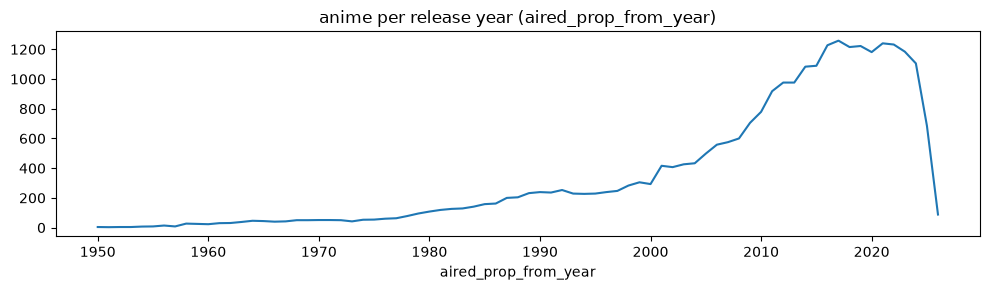

In [7]:
print("year NaN%:", round(anime.year.isna().mean()*100,1),
      "| aired_prop_from_year NaN/zero%:",
      round(((anime.aired_prop_from_year.isna())|(anime.aired_prop_from_year==0)).mean()*100,1))

yr = anime.aired_prop_from_year.replace(0, np.nan).dropna()
yr = yr[(yr>=1950)&(yr<=2026)]
plt.figure(figsize=(10,3))
yr.astype(int).value_counts().sort_index().plot(title="anime per release year (aired_prop_from_year)")
plt.tight_layout(); plt.show()

## 5. The rating graph (`rating.csv`) — the link-prediction target

This is the bipartite `Watcher — Anime` graph. Its degree distribution decides how we
subsample the 7.8M edges before the first embedding/GNN pass.

In [8]:
n_users, n_anime = rating.user_id.nunique(), rating.anime_id.nunique()
n_edges = len(rating)
print(f"edges={n_edges:,}  users={n_users:,}  anime={n_anime:,}")
print(f"density = {n_edges/(n_users*n_anime):.4f}")
unrated = (rating.rating==-1).sum()
print(f"rating==-1 (watched, unrated): {unrated:,} ({unrated/n_edges*100:.1f}%)  |  rated 1..10: {n_edges-unrated:,}")

edges=7,813,737  users=73,515  anime=11,200
density = 0.0095
rating==-1 (watched, unrated): 1,476,496 (18.9%)  |  rated 1..10: 6,337,241


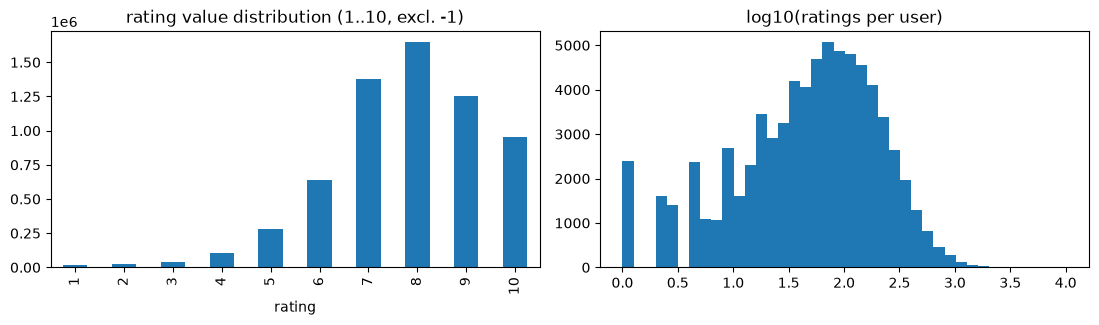

ratings per USER   {'mean': 106.28765558049378, '50%': 57.0, 'min': 1.0, 'max': 10227.0}
ratings per ANIME  {'mean': 697.6550892857143, '50%': 51.5, 'min': 1.0, 'max': 39340.0}


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
rating.loc[rating.rating>0, "rating"].value_counts().sort_index().plot.bar(
    ax=ax[0], title="rating value distribution (1..10, excl. -1)")
# per-user activity
udeg = rating.groupby("user_id").size()
adeg = rating.groupby("anime_id").size()
ax[1].hist(np.log10(udeg), bins=40); ax[1].set_title("log10(ratings per user)")
plt.tight_layout(); plt.show()

print("ratings per USER  ", udeg.describe()[["mean","50%","min","max"]].to_dict())
print("ratings per ANIME ", adeg.describe()[["mean","50%","min","max"]].to_dict())

In [10]:
# Long-tail check: how concentrated are edges? (drives subsampling strategy)
adeg_sorted = adeg.sort_values(ascending=False)
for frac in [0.01, 0.05, 0.1, 0.25]:
    k = max(1, int(len(adeg_sorted)*frac))
    share = adeg_sorted.head(k).sum()/n_edges*100
    print(f"top {frac*100:>4.0f}% of anime ({k:>5} titles) hold {share:5.1f}% of all edges")
print()
for thr in [5, 10, 20, 50]:
    kept_u = (udeg>=thr).sum()
    print(f"users with >= {thr:>3} ratings: {kept_u:>6,} ({kept_u/n_users*100:4.1f}% of users)")

top    1% of anime (  112 titles) hold  21.9% of all edges
top    5% of anime (  560 titles) hold  55.3% of all edges
top   10% of anime ( 1120 titles) hold  74.1% of all edges
top   25% of anime ( 2800 titles) hold  93.5% of all edges

users with >=   5 ratings: 66,870 (91.0% of users)
users with >=  10 ratings: 61,773 (84.0% of users)
users with >=  20 ratings: 54,190 (73.7% of users)
users with >=  50 ratings: 39,466 (53.7% of users)


## 6. Join coverage — do rated anime exist in anime.csv?

Every `Rating` node must point at an `Anime` node with content. Orphan edges = ratings
for anime absent from anime.csv (drop them at build time).

In [11]:
rated_ids = set(rating.anime_id.unique())
anime_ids = set(anime.mal_id.unique())
present = rated_ids & anime_ids
orphan = rated_ids - anime_ids
print(f"distinct rated anime: {len(rated_ids):,}")
print(f"present in anime.csv: {len(present):,} ({len(present)/len(rated_ids)*100:.1f}%)")
print(f"orphan (drop):        {len(orphan):,}")
orphan_edges = rating.anime_id.isin(orphan).sum()
print(f"orphan edges dropped: {orphan_edges:,} ({orphan_edges/n_edges*100:.2f}% of edges)")

distinct rated anime: 11,200
present in anime.csv: 11,127 (99.3%)
orphan (drop):        73
orphan edges dropped: 6,916 (0.09% of edges)


## Takeaways → triples stage

- **Dedup `mal_id`** (231 dup rows) before minting `:anime_<id>` IRIs.
- **`year` → use `aired_prop_from_year`** for `:releaseYear` (the `year` column is ~78% empty).
- **Multi-value fields**: split on `", "`, skip NaN, one shared node per value.
- **Missingness is the norm** for themes/demographics/licensors → emit an edge only when present
  (no null nodes).
- **Subsampling**: the graph is long-tailed. Filter to active users (e.g. `>= k` ratings) and/or
  a popular-anime core rather than a blind random sample — keeps the graph dense enough to embed.
  Decide the exact `k` next.
